In [ ]:
import time

import numpy as np
import cvxpy as cp

from scipy.stats import lognorm
from sklearn.model_selection import KFold

from tqdm import tqdm

import matplotlib.pyplot as plt

# Distributionally robust optimization

## 1. Постановка исходной задачи

Имеем задачу распределения m ресурсов на n задач:

$$
\begin{aligned}
&\max_{x\in\mathbb R^n} && \sum_{i=1}^n r_i\,x_i \\
&\text{s.t.} && \sum_{i=1}^n a_{ij}\,x_i \le b_j,\quad j=1,\dots,m,\\
& && x_i \ge 0,\quad i=1,\dots,n.
\end{aligned}
$$

Здесь

* $r_i$ — выгода от выполнения задачи $i$ (небольшое злоупотребление знаками: далее мы введём вектор непредвиденных «стоимостей»
  $c=-r$),
* $a_{ij}$ — требование ресурса $j$ для задачи $i$,
* $b_j$ — общий запас ресурса $j$.

Обозначим

$$
X = \bigl\{ x\ge0 \mid A x \le b \bigr\},\quad A_{ji}=a_{ij}.
$$

---

## 2. Формулировка задачи устойчивой оптимизации Вассерштейна (DRO) с нормой l1 для риск-аверсной целевой функции.

Пусть $r$ (а значит $c=-r$) — случайный вектор с неизвестным распределением $P^*$.
На основе $K$ выборок $c^{(k)}$, $k=1,\dots,K$, строим эмпирическое распределение

$$
\widehat P_0 = \frac1K\sum_{k=1}^K\delta_{c^{(k)}}.
$$

Задача **DRO с риско-аверсной функцией потерь** (CVaR уровня $\alpha$) формулируется как

$$
\min_{x\in X} \;\;
\Bigl\{\,\max_{P:\,W_q(P,\widehat P_0)\le\varepsilon}\;
\mathrm{CVaR}_\alpha^P\bigl(c^\top x\bigr)\Bigr\}.
$$

Здесь

* $W_q$ — Васерштейновская метрика порядка $q$ на множестве распределений,
* $\mathrm{CVaR}_\alpha^P(Z) = \min_{t\in\mathbb R}\!\bigl\{\,t+\tfrac1{1-\alpha}\,\mathbb E_P[(Z-t)_+]\bigr\}$.

---

Пусть дополнительно известна полигональная поддержка

$$
U=\{\,c\mid D\,c\le e\},
$$

тогда при $q=1$ (Wasserstein по $\ell_1$ и сопряжённая норма $\ell_\infty$) получается следующая **ЛП-реформулировка**:

$$
\begin{aligned}
&\underset{x,t,\lambda,\{\beta_k,\nu^{(k)}\}}{\min}
&& t \;+\;\frac1{1-\alpha}\Bigl(\,\varepsilon\,\lambda\;+\;\frac1K\sum_{k=1}^K\beta_k\Bigr)\\
&\text{s.t.}
&& x\in X,\quad \lambda\ge0,\;\beta_k\ge0,\;\nu^{(k)}\ge0,\quad k=1,\dots,K,\\
&&& (c^{(k)})^\top x - t \;+\;\bigl[e - D\,c^{(k)}\bigr]^\top\nu^{(k)}\;\le\;\beta_k,
\quad k=1,\dots,K,\\
&&& \|\,D^\top\nu^{(k)} - x\,\|_\infty \;\le\;\lambda,
\quad k=1,\dots,K.
\end{aligned}
$$

Здесь
$\Delta^{(k)}=e - D\,c^{(k)}\ge0$.

---

**Предположим, что выгоды r_i следуют логнормальному распределению**

In [31]:
alpha = 0.9

In [43]:
def generate_parameters(n):
    m = (int)(0.8 * n)
    a = np.random.uniform(0.5, 1.5, size=(n, m))
    b = np.random.uniform(5, 10, size=m)
    return a, b

def sample_r(n, size=1, mu_start=1.0, mu_step=0.01, sigma_start=0.5, sigma_step=0.001):
    mu = np.array([mu_start + i * mu_step for i in range(n)])
    sigma = np.array([sigma_start + i * sigma_step for i in range(n)])

    lognormal_matrix = np.zeros((size, n))
    for i in range(n):
        lognormal_matrix[:, i] = lognorm.rvs(s=sigma[i], scale=np.exp(mu[i]), size=size)

    return lognormal_matrix

def solve_risk_averse(a, b, r_samples, alpha=0.9):
    n = a.shape[0]
    x = cp.Variable(n)
    t = cp.Variable()
    z = cp.Variable(len(r_samples))

    objective = cp.Minimize(t + 1/(len(r_samples)*(1-alpha)) * cp.sum(z))
    constraints = [
        a.T @ x <= b,
        x >= 0,
        z >= 0,
        z >= - t - r_samples @ x
    ]
    problem = cp.Problem(objective, constraints)
    problem.solve()
    return x.value, t.value, objective.value

def do_risk_averse(r_samples, x, t, alpha):
    return t + 1/(1-alpha) * np.mean(np.maximum(-r_samples @ x - t, 0))

In [33]:
def solve_dro(c_samples, A, b, alpha, epsilon, D, e, q=1, solver=cp.GUROBI):
    """
    Решить DRO (CVaR + Wasserstein-1 или ∞) по ЛП-реформулировке.
    Возвращает dict с решением и временем решения.
    """
    K, n = c_samples.shape
    # переменные
    x    = cp.Variable(n)
    t    = cp.Variable()
    lam  = cp.Variable(nonneg=True)
    beta = cp.Variable(K, nonneg=True)
    nu   = cp.Variable((D.shape[0], K), nonneg=True)
    # Δ_k = e - D c^{(k)}
    Delta = e.reshape(-1,1) - D @ c_samples.T  # (dim_D, K)
    # ограничения
    constr = [A.T @ x <= b, x >= 0]
    for k in range(K):
        c_k = c_samples[k]
        Δk  = Delta[:, k]
        constr += [
            c_k @ x - t + Δk @ nu[:, k] <= beta[k]
        ]
        if q == 1:
            constr += [cp.norm_inf(D.T @ nu[:, k] - x) <= lam]
        else:
            constr += [cp.norm1(D.T @ nu[:, k] - x) <= lam]
    # цель
    obj = t + (1/(1 - alpha)) * (epsilon * lam + (1/K) * cp.sum(beta))
    prob = cp.Problem(cp.Minimize(obj), constr)
    t0 = time.time()
    prob.solve()
    return {
        'x': x.value,
        't': t.value,
        'lambda': lam.value,
        'beta': beta.value,
        'nu': nu.value,
        'obj': prob.value,
        'time': time.time() - t0
    }

In [34]:
def cross_validate_kfold(c_samples, A, b, alpha, eps_grid, D, e,
                         q=1, n_splits=3):
    """
    K-fold CV: для каждого ε усреднённая оценка val-cost по fold'ам.
    Возвращает dict ε→mean_val_cost.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    eps_costs = {eps: [] for eps in eps_grid}
    for train_idx, val_idx in kf.split(c_samples):
        c_train, c_val = c_samples[train_idx], c_samples[val_idx]
        _, _, Z_star = solve_risk_averse(A, b, c_val, alpha)
        for eps in eps_grid:
            sol = solve_dro(-c_train, A, b, alpha, eps, D, e, q)
            E_val = do_risk_averse(c_val, sol['x'], sol['t'], alpha=alpha) / Z_star
            eps_costs[eps].append(E_val)
    return {eps: np.mean(eps_costs[eps]) for eps in eps_grid}

In [46]:
def run_experiments(n_list, eps_grid, alpha=0.9, K=30, reps=100, m=None):
    """
    Классический эксперимент: для каждого n, eps, rep
     - генерируем данные
     - решаем DRO
     - оцениваем out-of-sample (mean cost)
    Возвращает dict n→list of {'epsilon','out','time'}.
    """
    # задаём U={c: D c ≤ e} как [-M,M]^n
    M = 20.0
    max_n = max(n_list)
    D = np.vstack([ np.eye(max_n), -np.eye(max_n) ])
    e = np.ones(2*max_n)*M

    all_res = {}
    cross_eps = {}
    for n in tqdm(n_list):
        recs = []
        eps_kfs = []
        for rep in range(reps):
            A, b = generate_parameters(n)

            # true out-of-sample grid
            train_samples = sample_r(n, size=K)
            test_samples = sample_r(n, size=10000)

            _, _, Z_star = solve_risk_averse(A, b, test_samples, alpha)

            for eps in eps_grid:
                sol = solve_dro(-train_samples, A, b, alpha, eps, D[:,:n], e, q=1)
                E_out = do_risk_averse(test_samples, sol['x'], sol['t'], alpha=alpha) / Z_star

                recs.append({'epsilon':eps, 'out':E_out, 'time':sol['time']})

            # cross
            kf_scores = cross_validate_kfold(-train_samples, A, b, alpha,
                                             eps_grid, D[:,:n], e, q=1, n_splits=3)
            eps_kfs.append(max(kf_scores, key=kf_scores.get))

        all_res[n] = recs
        cross_eps[n] = np.mean(eps_kfs)

    return all_res, cross_eps

In [36]:
def visualize_results(results, cross_eps, eps_grid):
    """
    Строит два графика:
      1) Средний out-of-sample cost vs ε с ±σ.
      2) Среднее время решения vs ε.
    """
    plt.figure()
    colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
    for i, (n, recs) in enumerate(results.items()):
        color = colors[i]
        means, stds = [], []
        for eps in eps_grid:
            outs = [r['out'] for r in recs if r['epsilon']==eps]
            means.append(np.mean(outs))
            stds.append(np.std(outs))
        plt.fill_between(eps_grid, np.array(means) - np.array(stds), np.array(means) + np.array(stds), color=color, alpha=0.2)
        plt.plot(eps_grid, means,  color=color, marker='o', linestyle='-', linewidth=2, label=f'n={n}')
        plt.axvline(x=cross_eps[n],  color=color, linestyle='--', label=None)
    plt.xlabel('Epsilon')
    plt.ylabel('Average out-of-sample cost')
    plt.title('Out-of-sample cost vs Epsilon')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    for n, recs in results.items():
        times = [np.mean([r['time'] for r in recs if r['epsilon']==eps])
                 for eps in eps_grid]
        plt.plot(eps_grid, times, marker='o', label=f'n={n}')
    plt.xlabel('Epsilon')
    plt.ylabel('Average solve time (s)')
    plt.title('Solve time vs Epsilon')
    plt.legend()
    plt.tight_layout()
    plt.show()

100%|██████████| 4/4 [05:15<00:00, 78.78s/it]


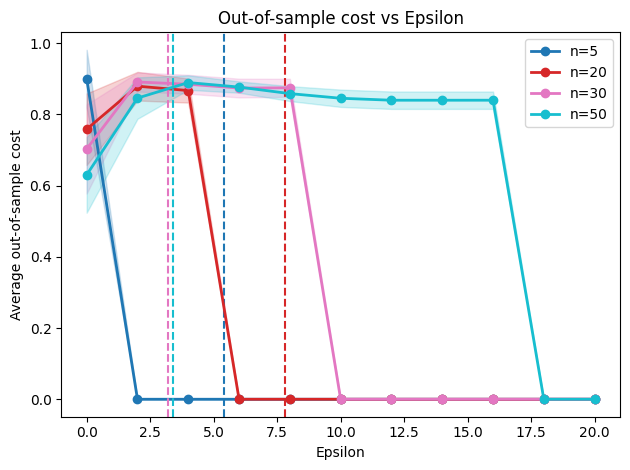

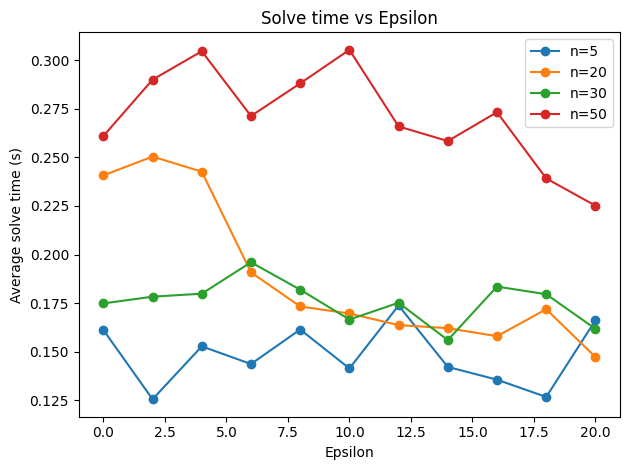

In [49]:
#n_list = range(5, 51, 5)
n_list = [5, 20, 30, 50]
reps = 10
K = 30
eps_grid = np.linspace(0, 20, 11)

results, cross_eps = run_experiments(n_list, eps_grid, alpha, K, reps)
visualize_results(results, cross_eps, eps_grid)

In [50]:
cross_eps

{5: np.float64(5.4),
 20: np.float64(7.8),
 30: np.float64(3.2),
 50: np.float64(3.4)}

100%|██████████| 6/6 [06:17<00:00, 62.84s/it]


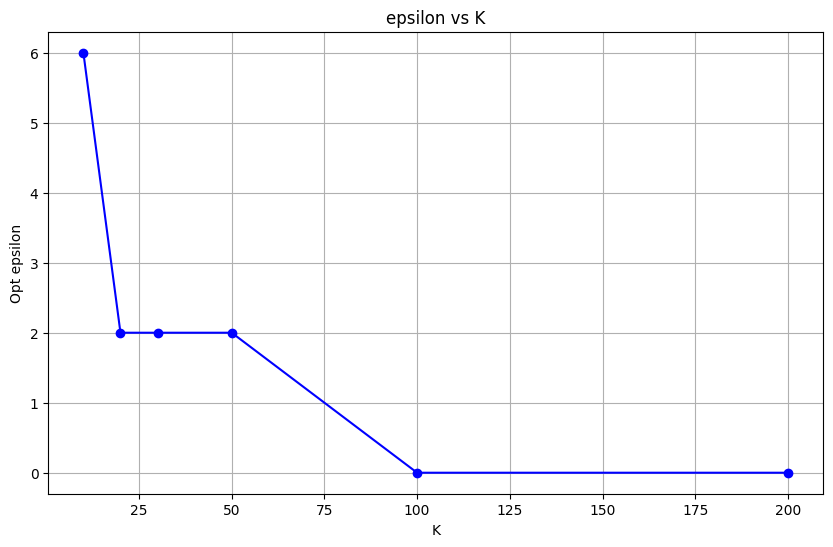

In [51]:
def run_experiments_for_different_K(n, eps_grid, alpha=0.9, K_list=[10, 20, 30, 50, 100], reps=10):
    """
    Запускает эксперименты для разных размеров выборки K и возвращает оптимальные значения ε.
    """
    # Задаём U={c: D c ≤ e} как [-M,M]^n
    M = 20.0
    D = np.vstack([np.eye(n), -np.eye(n)])
    e = np.ones(2*n)*M

    eps_optimal = {}

    for K in tqdm(K_list):
        eps_results = {eps: [] for eps in eps_grid}

        for rep in range(reps):
            A, b = generate_parameters(n)
            train_samples = sample_r(n, size=K)
            test_samples = sample_r(n, size=10000)

            _, _, Z_star = solve_risk_averse(A, b, test_samples, alpha)

            for eps in eps_grid:
                sol = solve_dro(-train_samples, A, b, alpha, eps, D[:,:n], e, q=1)
                E_out = do_risk_averse(test_samples, sol['x'], sol['t'], alpha=alpha) / Z_star
                eps_results[eps].append(E_out)

        mean_costs = {eps: np.mean(costs) for eps, costs in eps_results.items()}
        optimal_eps = max(mean_costs, key=mean_costs.get)
        eps_optimal[K] = optimal_eps

    return eps_optimal

n = 25
K_list = [10, 20, 30, 50, 100, 200]

eps_optimal = run_experiments_for_different_K(n, eps_grid, alpha=0.9, K_list=K_list, reps=reps)

plt.figure(figsize=(10, 6))
plt.plot(list(eps_optimal.keys()), list(eps_optimal.values()), marker='o', linestyle='-', color='b')
plt.xlabel('K')
plt.ylabel('Opt epsilon')
plt.title('epsilon vs K')
plt.grid(True)
plt.show()